# Dynamic Metric Weights: Weight Divergence vs. Loss

Visualize how the EWM weights for **Weight Divergence** and **Loss** evolve over communication rounds.

Data sources:
- `fmnist/fedgra_fmnist_min100_-train-20260617_191039-12dbf5cd_selection_log.csv`
- `mnist/fedgra_mnist_min100_-train-20260617_192203-c076d59e_selection_log.csv`


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Add repository root for style.py
root_dir = Path("../../..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from style import MatplotlibStyle

MatplotlibStyle().apply()


In [2]:
# ============================================================
# Load selection logs
# ============================================================

SELECTION_LOGS = {
    "FMNIST": Path("fmnist/fedgra_fmnist_min100_-train-20260617_191039-12dbf5cd_selection_log.csv"),
    "MNIST": Path("mnist/fedgra_mnist_min100_-train-20260617_192203-c076d59e_selection_log.csv"),
}

weight_dfs = {}
for name, csv_path in SELECTION_LOGS.items():
    df = pd.read_csv(csv_path)
    required_columns = {"round", "weight_divergence", "loss"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"{csv_path} missing columns: {sorted(missing_columns)}")

    weight_dfs[name] = df
    print(f"{name}: shape={df.shape}, rounds={df['round'].min()}-{df['round'].max()}")
    print(f"  WD range:   {df['weight_divergence'].min():.4f} to {df['weight_divergence'].max():.4f}")
    print(f"  Loss range: {df['loss'].min():.4f} to {df['loss'].max():.4f}")
    print(f"  WD + Loss max deviation: {(df['weight_divergence'] + df['loss'] - 1).abs().max():.6f}")


FMNIST: shape=(101, 4), rounds=0-100
  WD range:   0.3811 to 0.7844
  Loss range: 0.2156 to 0.6189
  WD + Loss max deviation: 0.000000
MNIST: shape=(101, 4), rounds=0-100
  WD range:   0.3035 to 0.8023
  Loss range: 0.1977 to 0.6965
  WD + Loss max deviation: 0.000000


In [ ]:
# ============================================================
# Plot helpers: WD up, Loss down
# ============================================================

def _draw_weight_dynamics_panel(
    ax,
    df,
    title,
    bar_width=1.4,
    y_lim=(-0.85, 0.85),
    x_ticks=(0, 25, 50, 75, 100),
    show_ylabel=True,
    show_legend=True,
    legend_loc="upper right",
):
    rounds = df["round"].to_numpy()
    wd_weights = df["weight_divergence"].to_numpy()
    loss_weights = df["loss"].to_numpy()

    ax.bar(
        rounds,
        wd_weights,
        width=bar_width,
        color="#2a7de1",
        edgecolor="white",
        linewidth=0.2,
        label="Weight Divergence",
    )
    ax.bar(
        rounds,
        -loss_weights,
        width=bar_width,
        color="#e53e3e",
        edgecolor="white",
        linewidth=0.2,
        label="Loss",
    )

    ax.set_title(title, fontsize=22, pad=4)
    ax.set_xlabel("Communication Round", fontsize=24)
    if show_ylabel:
        ax.set_ylabel("Metric Weight", fontsize=24)
    ax.set_xlim(-1, rounds.max() + 1)
    ax.set_ylim(y_lim)
    ax.set_xticks(x_ticks)

    y_ticks = [-0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{abs(t):.1f}" for t in y_ticks])
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=20)

    ax.axhline(y=0, color="black", linewidth=0.8)
    if show_legend:
        ax.legend(fontsize=18, loc=legend_loc, frameon=False, ncol=2)

def plot_weight_dynamics(
    df,
    title,
    save_path=None,
    figsize=(10, 5),
    bar_width=0.8,
    y_lim=(-0.85, 0.85),
    x_ticks=(0, 25, 50, 75, 100),
    legend_loc="upper right",
):
    fig, ax = plt.subplots(figsize=figsize)
    _draw_weight_dynamics_panel(
        ax,
        df,
        title=title,
        bar_width=bar_width,
        y_lim=y_lim,
        x_ticks=x_ticks,
        show_ylabel=True,
        show_legend=True,
        legend_loc=legend_loc,
    )
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=800, bbox_inches="tight")
    plt.show()

def plot_two_weight_dynamics(
    weight_dfs,
    dataset_names=("FMNIST", "MNIST"),
    save_path=None,
    figsize=(10, 5),
    bar_width=0.8,
    y_lim=(-0.85, 0.85),
    x_ticks=(0, 25, 50, 75, 100),
    legend_ncol=2,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.09),
):
    if len(dataset_names) != 2:
        raise ValueError("dataset_names must contain exactly two dataset names.")

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    handles = labels = None
    for idx, (ax, dataset_name) in enumerate(zip(axes, dataset_names)):
        _draw_weight_dynamics_panel(
            ax,
            weight_dfs[dataset_name],
            title=dataset_name,
            bar_width=bar_width,
            y_lim=y_lim,
            x_ticks=x_ticks,
            show_ylabel=(idx == 0),
            show_legend=False,
        )
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox_to_anchor,
        ncol=legend_ncol,
        fontsize=18,
        frameon=False,
    )

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=800, bbox_inches="tight")
    plt.show()


In [ ]:
# ============================================================
# FMNIST weight dynamics
# ============================================================

plot_weight_dynamics(
    weight_dfs["FMNIST"],
    title="FMNIST",
    save_path="fmnist_weight_dynamics.pdf",
)


In [ ]:
# ============================================================
# MNIST weight dynamics
# ============================================================

plot_weight_dynamics(
    weight_dfs["MNIST"],
    title="MNIST",
    save_path="mnist_weight_dynamics.pdf",
)


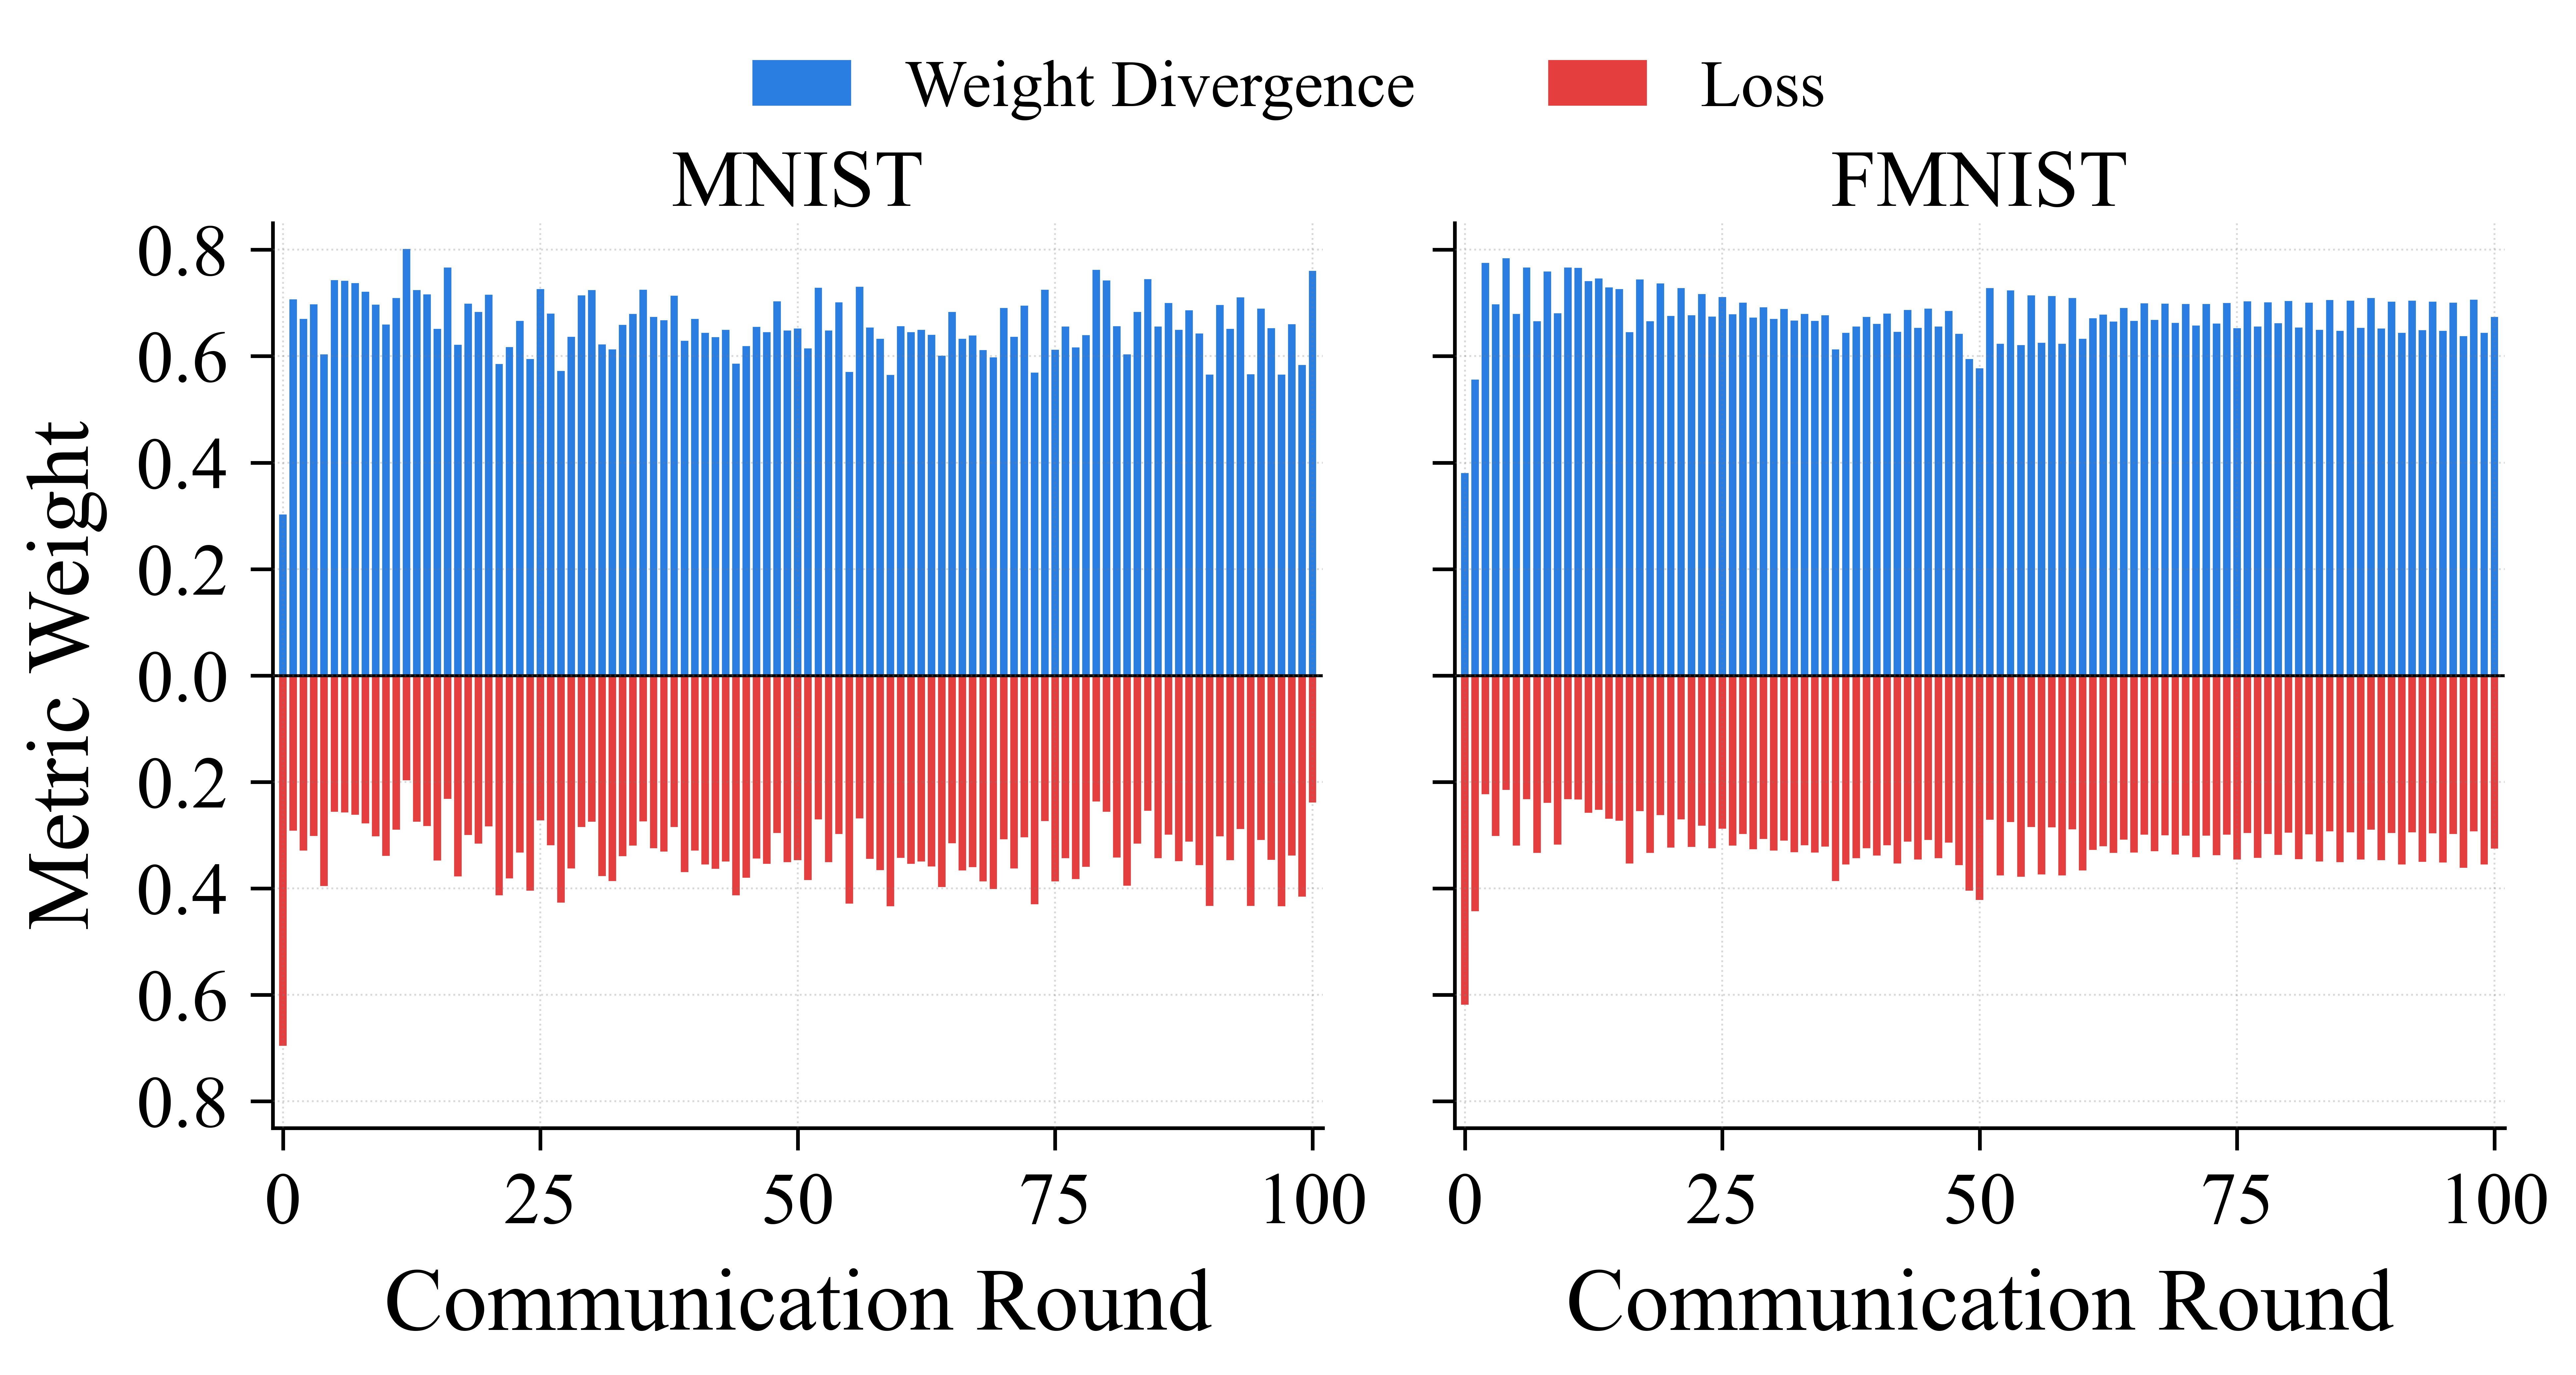

In [19]:
# ============================================================
# FMNIST and MNIST weight dynamics, side by side
# ============================================================

plot_two_weight_dynamics(
    weight_dfs,
    dataset_names=("MNIST", "FMNIST"),
    figsize=(10, 5),
    save_path="mnist_fmnist_weight_dynamics.pdf",
)
